## 1. Imports

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## 2. Config

In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "almaty_noise_training.csv"
ARTIFACTS_DIR = ROOT / "artifacts"

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET = "noise_level_dba"

## 3. Load Data

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
display(df.head())
display(df[TARGET].describe().to_frame().round(2))

Rows: 10,000
Columns: 11


,latitude,longitude,recorded_at,day_of_week,day_of_week_num,is_weekend,month,hour,period,noise_class,noise_level_dba
0,43.238371,76.914357,2026-02-25T15:14:34+05:00,Wednesday,2,0,2,15,daytime,others,52.82
1,43.237236,76.924403,2026-03-22T09:41:58+05:00,Sunday,6,1,3,9,morning,transport,68.87
2,43.233136,76.975432,2026-04-19T18:41:44+05:00,Sunday,6,1,4,18,evening,human,60.49
3,43.259635,76.943863,2026-02-23T11:52:08+05:00,Monday,0,0,2,11,daytime,transport,65.48
4,43.239064,76.927923,2026-01-30T08:02:45+05:00,Friday,4,0,1,8,morning,transport,83.41


,noise_level_dba
count,10000.00
mean,63.80
std,11.70
min,35.00
25%,56.51
50%,65.84
75%,72.50
max,91.36


## 4. Target Distribution

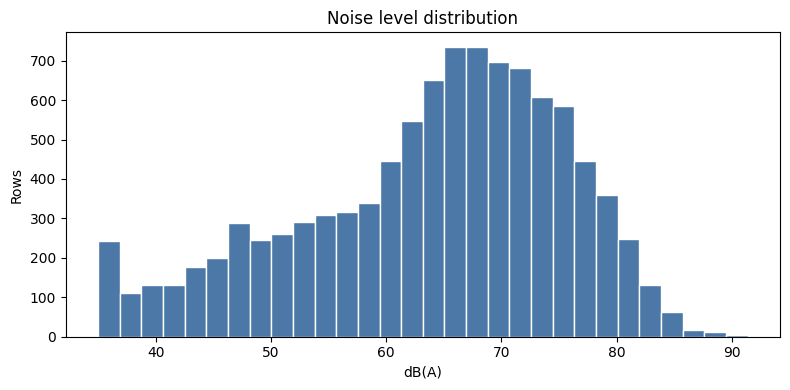

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(df[TARGET], bins=30, color="#4C78A8", edgecolor="white")
plt.title("Noise level distribution")
plt.xlabel("dB(A)")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [5]:
df = df.copy()
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week_num"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week_num"] / 7)

numeric_features = [
    "latitude",
    "longitude",
    "month",
    "hour",
    "day_of_week_num",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

categorical_features = ["period"]
feature_columns = numeric_features + categorical_features
X = df[feature_columns]
y = df[TARGET]

## 6. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Train rows: 8,000
Test rows: 2,000


## 7. Preprocessing And Model

In [7]:
def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", make_encoder(), categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=140,
                max_depth=18,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

## 8. Train

In [8]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)
residuals = y_test.to_numpy() - predictions

## 9. Metrics

In [9]:
metrics = {
    "mae": round(float(mean_absolute_error(y_test, predictions)), 4),
    "rmse": round(float(np.sqrt(mean_squared_error(y_test, predictions))), 4),
    "r2": round(float(r2_score(y_test, predictions)), 4),
}

display(pd.DataFrame([metrics]))

preview = X_test.copy().head(12)
preview["actual_noise_level_dba"] = y_test.head(12).to_numpy()
preview["predicted_noise_level_dba"] = np.round(predictions[:12], 2)
display(preview)

,mae,rmse,r2
0,2.6462,3.5371,0.91


,latitude,longitude,month,hour,day_of_week_num,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,period,actual_noise_level_dba,predicted_noise_level_dba
6252,43.221719,76.898488,12,9,4,0,0.707107,-7.071068e-01,-0.433884,-0.900969,morning,47.77,48.17
4684,43.218731,76.929812,4,16,1,0,-0.866025,-5.000000e-01,0.781831,0.623490,daytime,69.05,69.13
1731,43.214387,76.930011,11,19,5,1,-0.965926,2.588190e-01,-0.974928,-0.222521,evening,69.49,70.69
4742,43.237368,76.919202,2,20,0,0,-0.866025,5.000000e-01,0.000000,1.000000,evening,70.94,64.21
4521,43.249068,76.939728,11,9,1,0,0.707107,-7.071068e-01,0.781831,0.623490,morning,64.81,66.92
6340,43.260839,76.973417,3,7,1,0,0.965926,-2.588190e-01,0.781831,0.623490,morning,40.25,39.36
576,43.259470,76.973517,11,0,6,1,0.000000,1.000000e+00,-0.781831,0.623490,night,35.00,35.66
5202,43.257443,76.972055,3,20,2,0,-0.866025,5.000000e-01,0.974928,-0.222521,evening,35.93,39.70
6363,43.258719,76.975738,4,11,1,0,0.258819,-9.659258e-01,0.781831,0.623490,daytime,45.08,46.00
439,43.239350,76.915085,2,8,1,0,0.866025,-5.000000e-01,0.781831,0.623490,morning,62.72,66.61


## 10. Actual vs Predicted

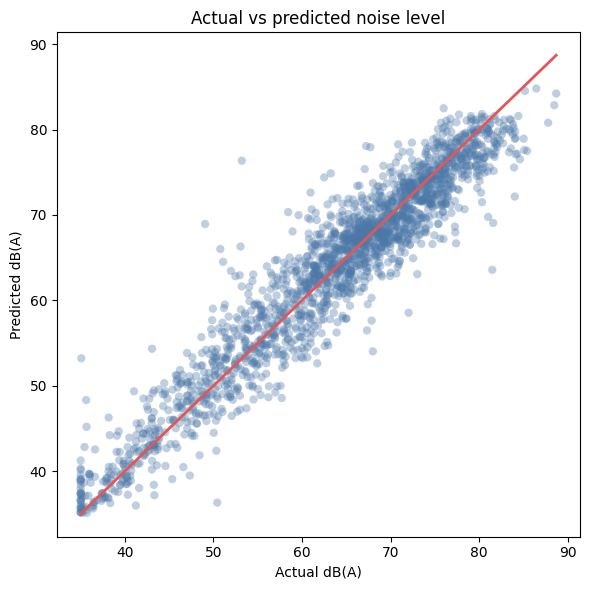

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.35, color="#4C78A8", edgecolors="none")
line_min = min(float(y_test.min()), float(predictions.min()))
line_max = max(float(y_test.max()), float(predictions.max()))
plt.plot([line_min, line_max], [line_min, line_max], color="#E15759", linewidth=2)
plt.title("Actual vs predicted noise level")
plt.xlabel("Actual dB(A)")
plt.ylabel("Predicted dB(A)")
plt.tight_layout()
plt.show()

## 11. Residuals

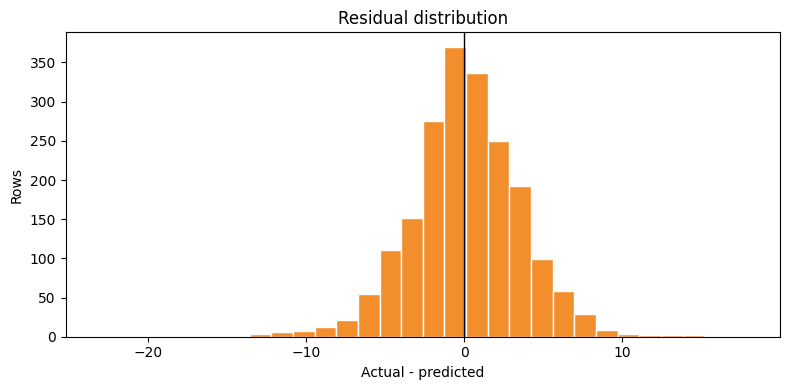

,mean_absolute_error
period,
daytime,2.496
late_evening,2.605
morning,2.679
evening,2.716
night,2.873


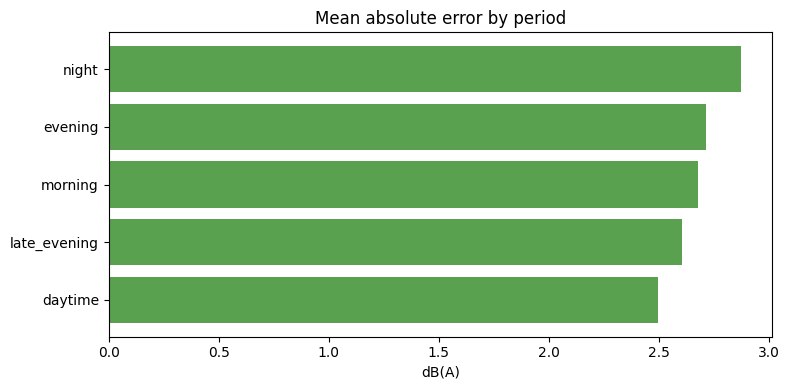

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, color="#F28E2B", edgecolor="white")
plt.axvline(0, color="black", linewidth=1)
plt.title("Residual distribution")
plt.xlabel("Actual - predicted")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

error_df = X_test.copy()
error_df["absolute_error"] = np.abs(residuals)
period_error = error_df.groupby("period")["absolute_error"].mean().sort_values()
display(period_error.round(3).to_frame("mean_absolute_error"))

plt.figure(figsize=(8, 4))
plt.barh(period_error.index, period_error.values, color="#59A14F")
plt.title("Mean absolute error by period")
plt.xlabel("dB(A)")
plt.tight_layout()
plt.show()

## 12. Feature Importance

,feature,importance
1,numeric__longitude,0.414275
0,numeric__latitude,0.290267
3,numeric__hour,0.118194
6,numeric__hour_sin,0.073248
7,numeric__hour_cos,0.029078
10,categorical__period_daytime,0.022717
4,numeric__day_of_week_num,0.016326
8,numeric__dow_sin,0.012572
2,numeric__month,0.011606
9,numeric__dow_cos,0.005939


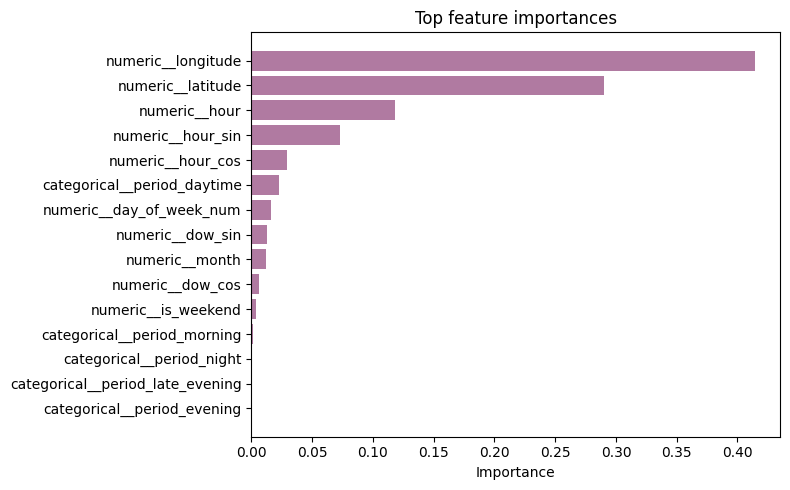

In [12]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#B07AA1")
plt.title("Top feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 13. Save Model

In [13]:
ARTIFACTS_DIR.mkdir(exist_ok=True)

model_path = ARTIFACTS_DIR / "noise_level_regressor.joblib"
metadata_path = ARTIFACTS_DIR / "noise_level_regressor_metadata.json"

joblib.dump(model, model_path, compress=3)

model_metadata = {
    "created_at": datetime.now(timezone.utc).isoformat().replace("+00:00", "Z"),
    "dataset_path": str(DATA_PATH.relative_to(ROOT)),
    "target": TARGET,
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "metrics": metrics,
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(model_metadata, file, ensure_ascii=False, indent=2)

print(f"Saved model: {model_path}")
print(f"Saved metadata: {metadata_path}")

Saved model: D:\Diploma\thesis-prediction-microservice\artifacts\noise_level_regressor.joblib
Saved metadata: D:\Diploma\thesis-prediction-microservice\artifacts\noise_level_regressor_metadata.json
